# Time Series Prediction with PyTorch

In [1]:
import random
import time
import tempfile
from pathlib import Path

import lightning.pytorch as pl
import pandas as pd
from matplotlib import pyplot as plt

from pytorch_forecasting import DeepAR, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.data.examples import generate_ar_data

import ray
from ray.train.torch import TorchTrainer
from ray.train import ScalingConfig, Checkpoint
from ray.train.lightning import RayTrainReportCallback

Initialize Ray and allocate cluster resources.

---

In [2]:
if ray.is_initialized():
    ray.shutdown()

ray.init(address="auto")
display(ray.cluster_resources())

total_nodes = 4
total_gpus = 1
total_cpus = 4

scaling_config = ScalingConfig(
    num_workers=total_nodes,
    use_gpu=True,
    resources_per_worker={"CPU": total_cpus, "GPU": total_gpus},
)

2026-05-29 10:21:42,404	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 172.22.26.2:53515...
2026-05-29 10:21:42,423	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://172.22.26.2:8265 
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


{'node:172.22.26.2': 1.0,
 'object_store_memory': 238508040192.0,
 'memory': 556518760448.0,
 'CPU': 16.0,
 'GPU': 4.0,
 'accelerator_type:V100': 2.0,
 'node:__internal_head__': 1.0,
 'node:172.22.26.3': 1.0}

Generate synthetic time series data and load it into the Ray object store to prevent serialization bottlenecks.

---

In [3]:
data = generate_ar_data(seasonality=10.0, timesteps=400, n_series=2000, seed=42)
data["date"] = pd.Timestamp("2020-01-01") + pd.to_timedelta(data.time_idx, "D")
data["series"] = data["series"].astype(str)

data_ref = ray.put(data)

display(data.head())

,series,time_idx,value,date
0,0,0,-0.000000,2020-01-01
1,0,1,0.138983,2020-01-02
2,0,2,0.284049,2020-01-03
3,0,3,0.454750,2020-01-04
4,0,4,0.619239,2020-01-05


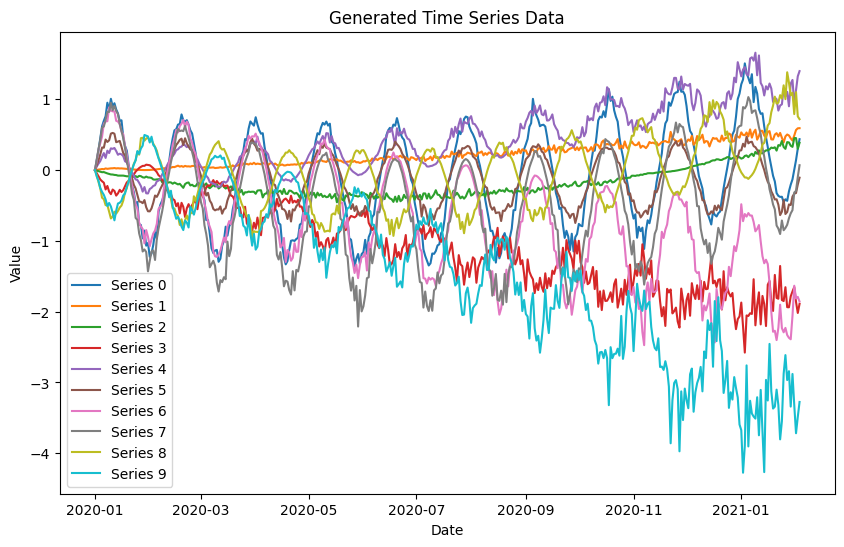

In [4]:
plt.figure(figsize=(10, 6))

for series_id in data.series.unique()[:10]:
    series_data = data[data.series == series_id]
    plt.plot(
        series_data.date,
        series_data.value,
        label=f"Series {series_id}",
    )

plt.legend()
plt.title("Generated Time Series Data")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

Create the training and validation datasets using `TimeSeriesDataSet`. The validation set is generated using `from_dataset()` to ensure the categorical encoders and scalers perfectly match the training set.

---

In [5]:
def get_datasets(data):
    max_encoder_length = 60
    max_prediction_length = 20
    training_cutoff = data["time_idx"].max() - max_prediction_length

    training = TimeSeriesDataSet(
        data[lambda x: x.time_idx <= training_cutoff],
        time_idx="time_idx",
        target="value",
        group_ids=["series"],
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        static_categoricals=["series"],
        time_varying_known_reals=["time_idx"],
        time_varying_unknown_reals=["value"],
        categorical_encoders={"series": NaNLabelEncoder().fit(data.series)},
    )

    validation = TimeSeriesDataSet.from_dataset(
        training,
        data,
        min_prediction_idx=training.index.time.max() + 1,
        stop_randomization=True,
    )

    return training, validation

Define the distributed training function. This logic runs securely on each Ray worker. Early stopping and checkpointing are disabled to ensure a strict 10-epoch performance benchmark.

---

In [6]:
def train_func(config):
    data = ray.get(config["data_ref"])
    training, validation = get_datasets(data)

    pl.seed_everything(42, workers=True)

    dataloader_workers = config["dataloader_workers"]
    batch_size = 256

    train_dataloader = training.to_dataloader(
        train=True,
        batch_size=batch_size,
        num_workers=dataloader_workers,
        # persistent_workers=dataloader_workers > 0,
    )

    val_dataloader = validation.to_dataloader(
        train=False,
        batch_size=batch_size,
        num_workers=dataloader_workers,
        # persistent_workers=dataloader_workers > 0,
    )

    # model = DeepAR.from_dataset(training)
    model = TemporalFusionTransformer.from_dataset(training)

    trainer = pl.Trainer(
        max_epochs=10,
        accelerator="gpu",
        devices="auto",
        gradient_clip_val=0.1,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        strategy=ray.train.lightning.RayDDPStrategy(),
        plugins=[ray.train.lightning.RayLightningEnvironment()],
        callbacks=[RayTrainReportCallback()],
    )

    trainer = ray.train.lightning.prepare_trainer(trainer)

    trainer.fit(
        model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader
    )

    with tempfile.TemporaryDirectory() as tmp_dir:
        checkpoint_path = Path(tmp_dir) / "checkpoint.ckpt"
        trainer.save_checkpoint(checkpoint_path)
        ray.train.report(metrics={}, checkpoint=Checkpoint.from_directory(tmp_dir))

Launch the distributed training job.

---

In [7]:
ray_trainer = TorchTrainer(
    train_func,
    train_loop_config={"data_ref": data_ref, "dataloader_workers": total_cpus - 1},
    scaling_config=scaling_config,
)

start_time = time.time()
result = ray_trainer.fit()
print(f"Distributed Training Time: {time.time() - start_time:.2f} seconds")

(TrainController pid=2851640) Requesting resources: {'CPU': 4, 'GPU': 1} * 4
(TrainController pid=2851640) Attempting to start training worker group of size 4 with the following resources: [{'CPU': 4, 'GPU': 1}] * 4
(RayTrainWorker pid=3832593, ip=172.22.26.3) Setting up process group for: env:// [rank=0, world_size=4]
(TrainController pid=2851640) Started training worker group of size 4: 
(TrainController pid=2851640) - (ip=172.22.26.3, pid=3832593) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=2851640) - (ip=172.22.26.3, pid=3832594) world_rank=1, local_rank=1, node_rank=0
(TrainController pid=2851640) - (ip=172.22.26.2, pid=2851786) world_rank=2, local_rank=0, node_rank=1
(TrainController pid=2851640) - (ip=172.22.26.2, pid=2851787) world_rank=3, local_rank=1, node_rank=1
(RayTrainWorker pid=2851786) INFO: [rank: 2] Seed set to 42
(RayTrainWorker pid=2851786) [rank: 2] Seed set to 42
(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs

Sanity Checking: |          | 0/? [00:00<?, ?it/s] 
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]


(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('sanity_check_loss', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('sanity_check_SMAPE', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('sanity_check_MAE', ..., sync_dist=T

                                                                           
Epoch 0: 100%|██████████| 587/587 [00:35<00:00, 16.62it/s, train_loss_step=0.0837]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation: |          | 0/? [00:00<?, ?it/s]) 
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation: |          | 0/? [00:00<?, ?it/s]) 
Validation DataLoader 0:   1%|▏         | 2/157 [00:00<00:04, 31.03it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   3%|▎         | 4/157 [00:00<00:05, 29.45it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   4%|▍         | 7/157 [00:00<00:05, 27.81it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   6%|▌         | 9/157 [00:00<00:05, 26.73it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   8%|▊         | 12/157 [00:00<00:05, 25.98it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   9%|▉         | 14/157 [00:00<0

(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('val_loss', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('val_SMAPE', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=3832593, ip=172.22.26.3) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('val_MAE', ..., sync_dist=True)` when logging on epoch

...

Epoch 8: 100%|██████████| 587/587 [00:36<00:00, 16.18it/s, train_loss_step=0.0592, val_loss=0.107, train_loss_epoch=0.0701]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation: |          | 0/? [00:00<?, ?it/s]) 
Validation: |          | 0/? [00:00<?, ?it/s]) 
Validation DataLoader 0:   0%|          | 0/157 [00:00<?, ?it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   1%|▏         | 2/157 [00:00<00:06, 23.51it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   3%|▎         | 4/157 [00:00<00:06, 22.91it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   4%|▍         | 6/157 [00:00<00:07, 21.28it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   6%|▌         | 9/157 [00:00<00:06, 22.75it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   7%|▋         | 11/157 [00:00<00:06, 22.05it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   

(RayTrainWorker pid=2851786) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-05-29_10-21-44/checkpoint_2026-05-29_10-28-35.149378) [repeated 4x across cluster]
(RayTrainWorker pid=2851786) Reporting training result 9: TrainingReport(checkpoint=Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-05-29_10-21-44/checkpoint_2026-05-29_10-28-35.149378), metrics={'train_loss': 0.07014904171228409, 'train_loss_step': 0.06898237764835358, 'val_loss': 0.10836782306432724, 'val_SMAPE': 0.11283823102712631, 'val_MAE': 0.2006750851869583, 'val_RMSE': 0.36682775616645813, 'val_MAPE': 0.1504194587469101, 'train_loss_epoch': 0.07014904171228409, 'epoch': 8, 'step': 5283}, validation=False) [repeated 4x across cluster]


Epoch 9: 100%|██████████| 587/587 [00:36<00:00, 16.11it/s, train_loss_step=0.0677, val_loss=0.108, train_loss_epoch=0.0696]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation: |          | 0/? [00:00<?, ?it/s]) 
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation: |          | 0/? [00:00<?, ?it/s]) 
Validation DataLoader 0:   0%|          | 0/157 [00:00<?, ?it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   1%|▏         | 2/157 [00:00<00:10, 15.04it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   3%|▎         | 4/157 [00:00<00:07, 20.08it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   4%|▍         | 7/157 [00:00<00:07, 20.53it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   6%|▌         | 9/157 [00:00<00:06, 21.77it/s]
(RayTrainWorker pid=3832593, ip=172.22.26.3) 
Validation DataLoader 0:   8%|▊         | 12/157 [00:00<00:06, 22.51it/s]
(RayTrainWorker pid=3832593

(RayTrainWorker pid=3832594, ip=172.22.26.3) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-05-29_10-21-44/checkpoint_2026-05-29_10-29-18.583628) [repeated 4x across cluster]
(RayTrainWorker pid=3832594, ip=172.22.26.3) Reporting training result 10: TrainingReport(checkpoint=Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-05-29_10-21-44/checkpoint_2026-05-29_10-29-18.583628), metrics={'train_loss': 0.06917786598205566, 'train_loss_step': 0.07277234643697739, 'val_loss': 0.10770944505929947, 'val_SMAPE': 0.11588985472917557, 'val_MAE': 0.2000730335712433, 'val_RMSE': 0.3647138476371765, 'val_MAPE': 0.15867964923381805, 'train_loss_epoch': 0.06917786598205566, 'epoch': 9, 'step': 5870}, validation=False) [repeated 4x across cluster]
(RayTrainWorker pid=2851786) INFO: `weights_only` was not set, defaulting to `False`.
(RayTrainWorker pid=2851786) `weights_only` 

Epoch 9: 100%|██████████| 587/587 [00:43<00:00, 13.51it/s, train_loss_step=0.0677, val_loss=0.107, train_loss_epoch=0.0691]
Distributed Training Time: 459.59 seconds


Plot a sample of results. We sample 5 series prior to generating predictions.

---

/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seaml

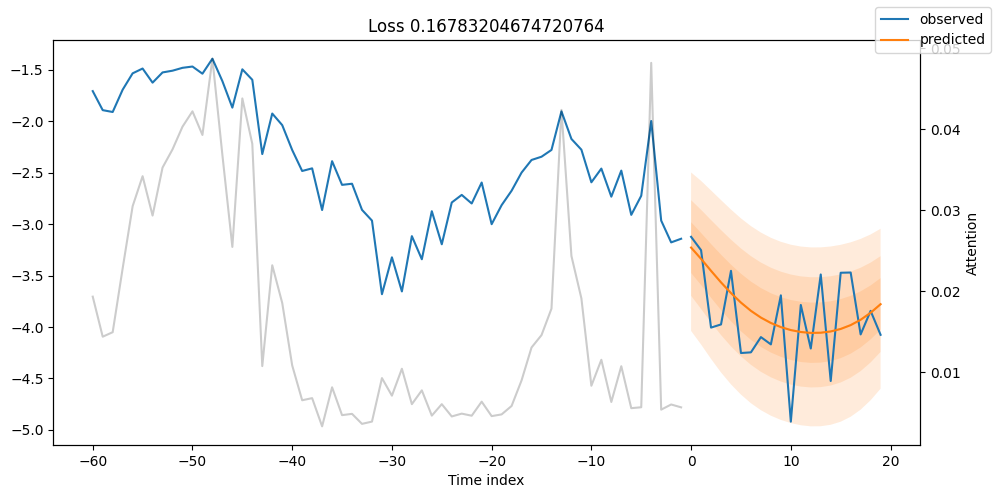

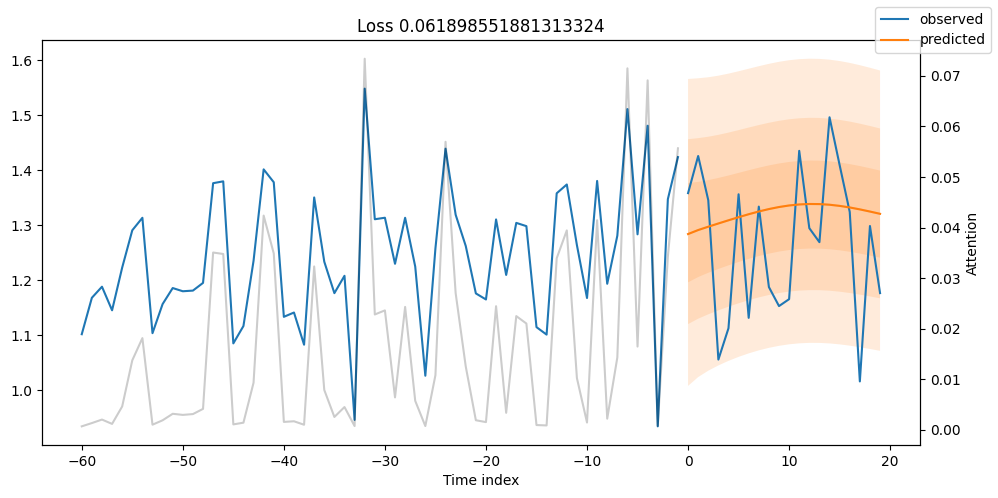

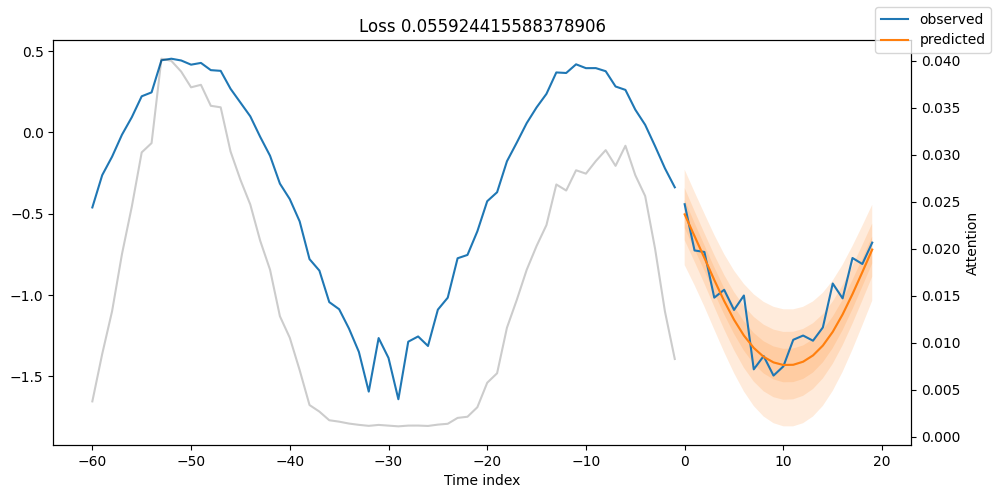

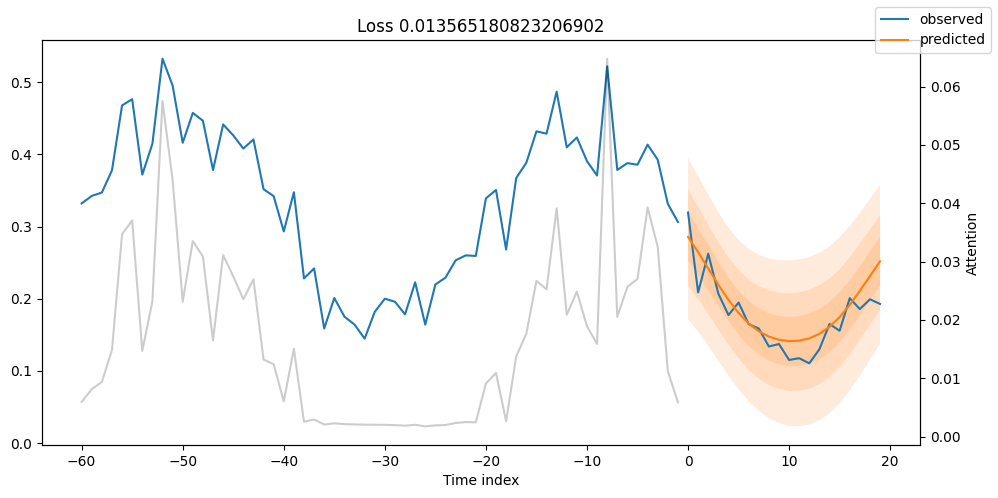

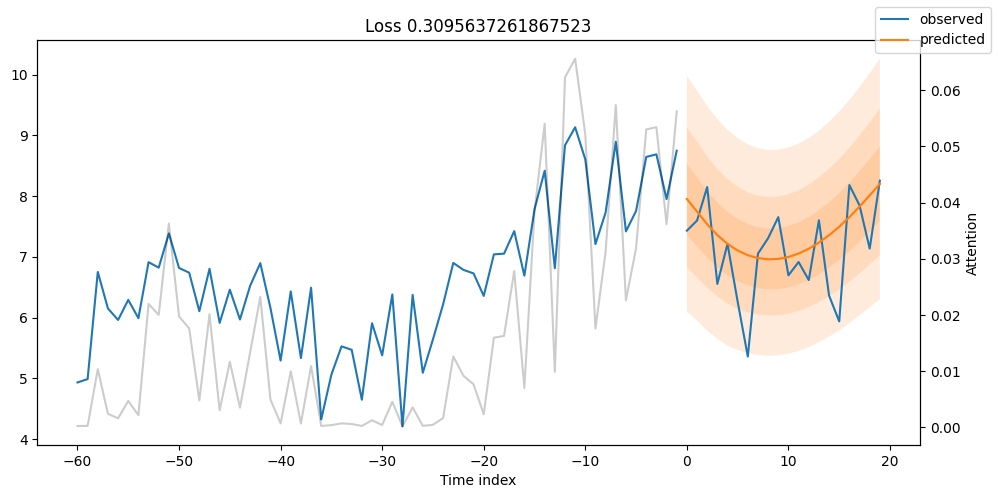

In [8]:
with result.checkpoint.as_directory() as checkpoint_dir:
    checkpoint_path = Path(checkpoint_dir) / "checkpoint.ckpt"
    best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_path)

sample_series_ids = random.sample(list(data["series"].unique()), 5)

sample_data = data[data["series"].isin(sample_series_ids)]

raw_predictions = best_model.predict(sample_data, mode="raw", return_x=True)

for idx in range(len(sample_series_ids)):
    fig, ax = plt.subplots(figsize=(10, 5))
    best_model.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=idx,
        add_loss_to_title=True,
        ax=ax,
    )
    plt.show()